In [27]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [28]:
df_ind = df[df['job_country'] == 'India'].copy()

In [29]:
df_ind.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
94089,Business Analyst,Business Analyst,India,via Emprego.pt,Full-time,False,India,2023-03-02 00:22:36,False,False,India,None,NaN,NaN,Confidential,"['python', 'sql', 'tableau', 'alteryx']","{'analyst_tools': ['tableau', 'alteryx'], 'pro..."
636279,Data Engineer,Sr. Process Data Engineer,"Chennai, Tamil Nadu, India",via Indeed,Full-time,False,India,2023-01-03 21:42:22,False,False,India,None,NaN,NaN,Shell,"['shell', 'windows', 'outlook', 'excel', 'powe...","{'analyst_tools': ['outlook', 'excel', 'power ..."
487835,Data Engineer,Lead Consultant - Data Engineer,"Noida, Uttar Pradesh, India",via Indeed,Full-time,False,India,2023-04-25 11:13:16,False,False,India,None,NaN,NaN,Genpact,"['go', 'sql', 'python', 'snowflake', 'aws', 'g...","{'cloud': ['snowflake', 'aws'], 'libraries': [..."
265255,Data Engineer,Data Management Engineer - ME GPS,"Bommasandra, Karnataka, India",via General Motors Careers,Full-time,False,India,2023-02-10 07:51:21,False,False,India,None,NaN,NaN,General Motors,"['assembly', 'sharepoint']","{'analyst_tools': ['sharepoint'], 'programming..."
444657,Data Engineer,Power BI Developer and Snowflake Data Engineer,"Maharashtra, India",via Shine,Full-time,False,India,2023-11-13 16:50:30,True,False,India,None,NaN,NaN,Yantra,"['sql', 'snowflake', 'power bi', 'dax']","{'analyst_tools': ['power bi', 'dax'], 'cloud'..."
282357,Senior Data Scientist,Senior Data Scientist,"Ahmedabad, Gujarat, India",via LinkedIn,Full-time,False,India,2023-03-22 07:27:46,False,False,India,None,NaN,NaN,Tecxar,"['r', 'python', 'sql']","{'programming': ['r', 'python', 'sql']}"
163188,Data Scientist,Data Scientist,"Chennai, Tamil Nadu, India",via Ai-Jobs.net,Full-time,False,India,2023-07-04 15:12:51,False,False,India,year,157500.0,NaN,Sutherland,['sheets'],{'analyst_tools': ['sheets']}
258053,Data Engineer,Data Engineer,"Bengaluru, Karnataka, India",via BeBee India,Full-time,False,India,2023-02-15 07:30:54,True,False,India,None,NaN,NaN,LatentView Analytics,"['sql', 'python', 'pyspark', 'github', 'gitlab...","{'async': ['jira'], 'libraries': ['pyspark'], ..."
785308,Data Engineer,for Data Engineer IT,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-06-10 06:12:19,False,False,India,None,NaN,NaN,VAS India Consulting,"['sql', 'nosql', 'python', 'java', 'c++', 'sca...","{'databases': ['cassandra'], 'libraries': ['ha..."
209333,Senior Data Engineer,Senior Data Engineer,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-09-22 22:34:22,False,False,India,None,NaN,NaN,NTT Ltd.,"['python', 'sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['..."


In [30]:
df_ind['job_posted_month'] = df_ind['job_posted_date'].dt.strftime('%B')

In [31]:
df_ind_pivot = df_ind.pivot_table(index= 'job_posted_month', columns=  'job_title_short', aggfunc= 'size')

In [32]:
df_ind_pivot.reset_index(inplace= True)

df_ind_pivot['Month_Number']= pd.to_datetime(df_ind_pivot['job_posted_month'], format='%B').dt.month

df_ind_pivot['Month_Number']


0      4
1      8
2     12
3      2
4      1
5      7
6      6
7      3
8      5
9     11
10    10
11     9
Name: Month_Number, dtype: int32

In [37]:
df_ind_pivot.sort_values('Month_Number', inplace= True)

df_ind_pivot.set_index('job_posted_month',inplace=  True)

df_ind_pivot.drop(columns= 'Month_Number', inplace= True)

In [38]:
df_ind_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,175,31,628,2132,1444,70,127,448,269,192
February,143,35,433,1631,932,42,94,313,165,157
March,116,37,422,1591,1005,34,96,351,194,180
April,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
June,146,26,367,1632,1129,41,66,427,238,125
July,142,25,457,1528,1123,54,75,359,204,155
August,189,25,618,1407,1157,47,126,343,235,148
September,155,34,630,1508,984,67,85,324,195,132


<Axes: xlabel='job_posted_month'>

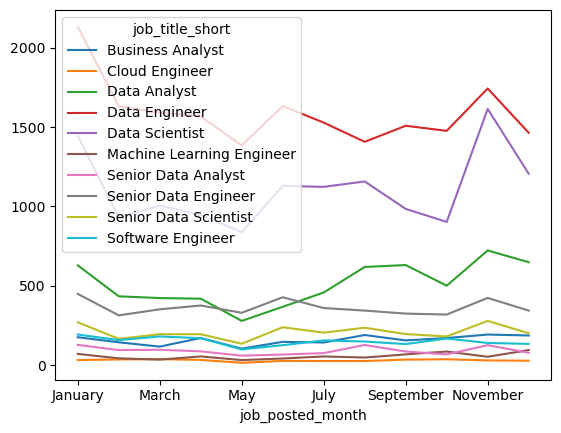

In [43]:
df_ind_pivot.plot(kind='line')

In [44]:
top_3 = df_ind['job_title_short'].value_counts().head(3)

In [47]:
top_3 = top_3.index.tolist()

In [48]:
top_3

['Data Engineer', 'Data Scientist', 'Data Analyst']

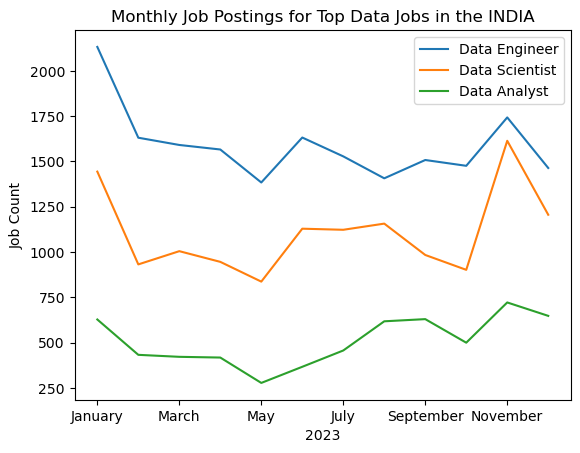

In [51]:
df_ind_pivot[top_3].plot(kind= 'line')

plt.title('Monthly Job Postings for Top Data Jobs in the INDIA')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()